# Data Vision

## Extracción de datos

Se leen los archivos en `test/results` y se guarda toda la información del header por **dimensión** y **random steps**. La variable `data` es un dict: `data[dimension][random_steps]` contiene el dict con toda la info del archivo.

In [14]:
import re
from pathlib import Path

RESULTS_DIR = Path("test/results")
if not RESULTS_DIR.exists():
    raise FileNotFoundError("No se encontró test/results. Ejecuta desde la raíz del proyecto (try/).")

def parse_result_file(filepath):
    """Extrae del header toda la info: dimension, random_steps, boards_count, times_ms, solution_steps, mean_time_ms, mean_solution_steps."""
    text = filepath.read_text(encoding="utf-8")
    head = text.split("##############")[0]
    dim = re.search(r"Dimension:\s*(\d+)", head)
    steps = re.search(r"Random Steps:\s*(\d+)", head)
    boards = re.search(r"Boards Count:\s*(\d+)", head)
    times = re.search(r"Times \(ms\):\s*\[([^\]]+)\]", head)
    sol = re.search(r"Solution Steps:\s*\[([^\]]+)\]", head)
    mean_t = re.search(r"Mean Time \(ms\):\s*([\d.]+)", head)
    mean_s = re.search(r"Mean Solution Steps:\s*([\d.]+)", head)
    return {
        "dimension": int(dim.group(1)) if dim else None,
        "random_steps": int(steps.group(1)) if steps else None,
        "boards_count": int(boards.group(1)) if boards else None,
        "times_ms": [int(x.strip()) for x in times.group(1).split(",")] if times else [],
        "solution_steps": [int(x.strip()) for x in sol.group(1).split(",")] if sol else [],
        "mean_time_ms": float(mean_t.group(1)) if mean_t else None,
        "mean_solution_steps": float(mean_s.group(1)) if mean_s else None,
    }

# data[dimension][random_steps] = info con toda la data del header
data = {}
for f in sorted(RESULTS_DIR.glob("*.txt")):
    try:
        info = parse_result_file(f)
        if info["dimension"] is None or info["random_steps"] is None:
            continue
        dim, steps = info["dimension"], info["random_steps"]
        if dim not in data:
            data[dim] = {}
        data[dim][steps] = info
    except Exception as e:
        print(f"Skip {f.name}: {e}")

## 1. Gráfica de línea: progreso de 3 valores por set
Cada set tiene 3 valores (progreso); un color y etiqueta por set.

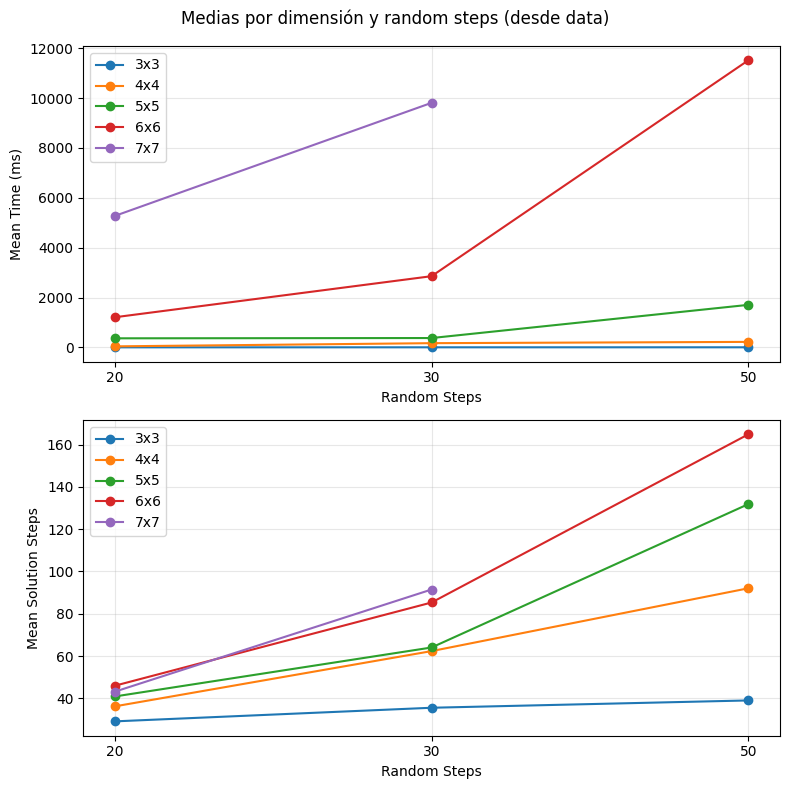

In [15]:
import matplotlib.pyplot as plt
import numpy as np

random_steps_order = [20, 30, 50]
x = np.arange(3)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

for dim in sorted(data.keys()):
    label = f"{dim}x{dim}"
    vals_t = [data[dim].get(s, {}).get("mean_time_ms") for s in random_steps_order]
    vals_s = [data[dim].get(s, {}).get("mean_solution_steps") for s in random_steps_order]
    if any(v is not None for v in vals_t):
        ax1.plot(x, vals_t, marker="o", label=label)
    if any(v is not None for v in vals_s):
        ax2.plot(x, vals_s, marker="o", label=label)

for ax in (ax1, ax2):
    ax.set_xticks(x)
    ax.set_xticklabels(["20", "30", "50"])
    ax.set_xlabel("Random Steps")
    ax.legend()
    ax.grid(True, alpha=0.3)
ax1.set_ylabel("Mean Time (ms)")
ax2.set_ylabel("Mean Solution Steps")
plt.suptitle("Medias por dimensión y random steps (desde data)")
plt.tight_layout()
plt.show()

## 2. Dispersión 1D: varios sets, un color por set
Cada set es un arreglo unidimensional; se muestra cómo están dispersos sus valores (eje Y = valor, eje X = banda por set con jitter).

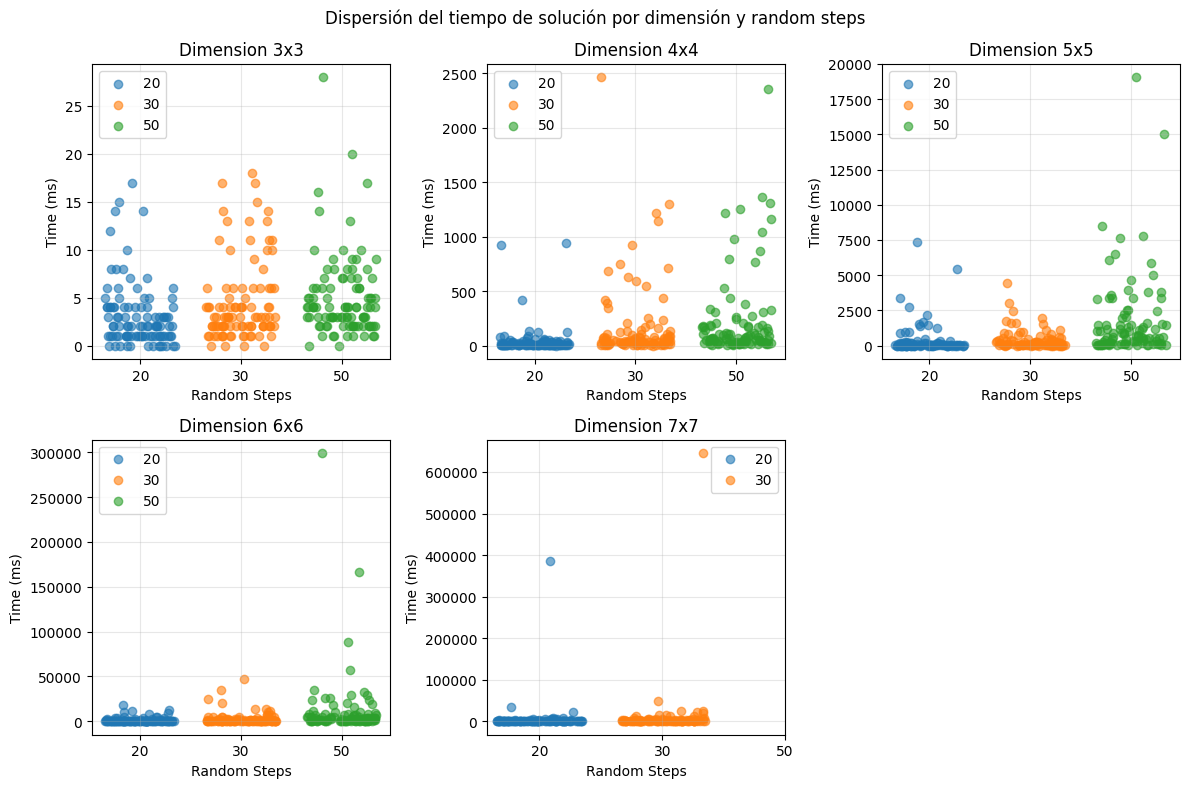

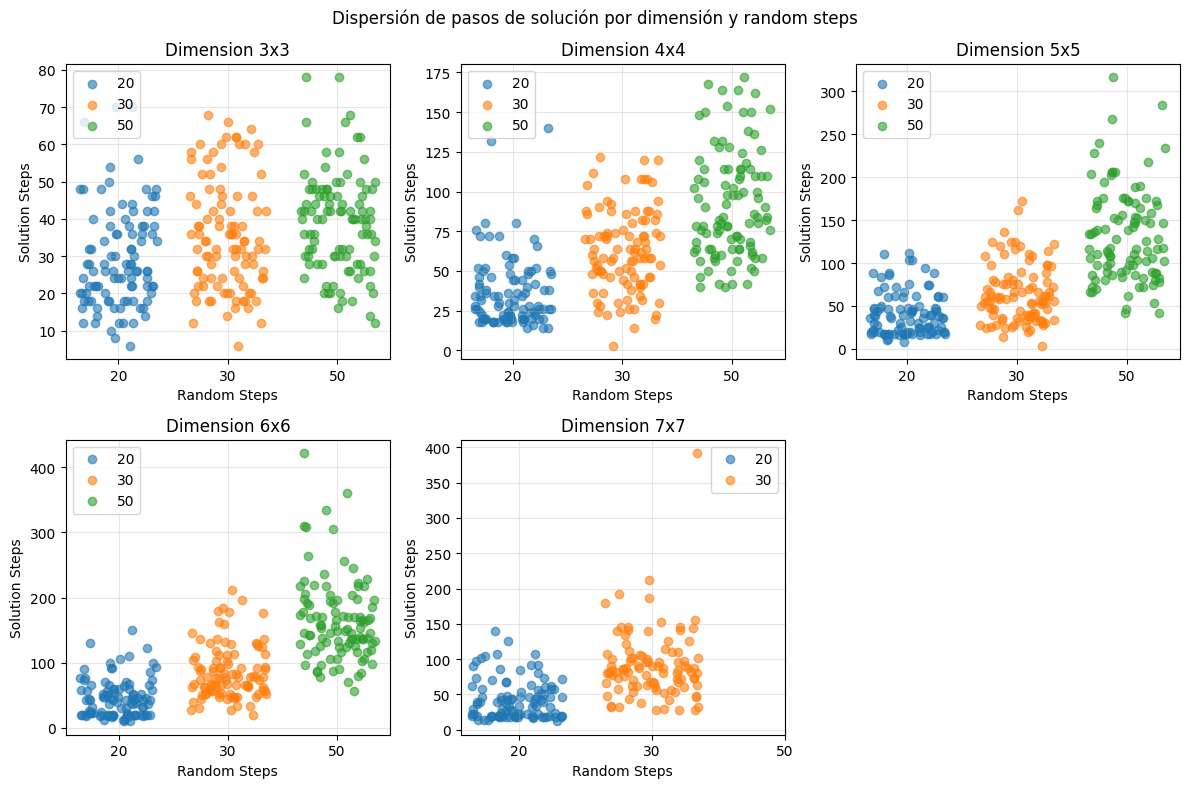

In [16]:
import matplotlib.pyplot as plt
import numpy as np

dimensions = sorted(data.keys())
random_steps_labels = [20, 30, 50]
data_times = {(dim, steps): info["times_ms"] for dim in data for steps, info in data[dim].items()}
data_steps = {(dim, steps): info["solution_steps"] for dim in data for steps, info in data[dim].items()}
np.random.seed(42)

# 1) Dispersión de Time (ms) por dimensión y random steps
fig1, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for idx, dim in enumerate(dimensions):
    ax = axes[idx] if idx < len(axes) else axes[-1]
    for i, steps in enumerate(random_steps_labels):
        key = (dim, steps)
        if key not in data_times:
            continue
        arr = np.array(data_times[key])
        x = i + np.random.uniform(-0.35, 0.35, len(arr))
        ax.scatter(x, arr, label=str(steps), alpha=0.6)
    ax.set_title(f"Dimension {dim}x{dim}")
    ax.set_xticks(range(len(random_steps_labels)))
    ax.set_xticklabels([str(s) for s in random_steps_labels])
    ax.set_xlabel("Random Steps")
    ax.set_ylabel("Time (ms)")
    ax.legend()
    ax.grid(True, alpha=0.3)
for j in range(len(dimensions), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Dispersión del tiempo de solución por dimensión y random steps")
plt.tight_layout()
plt.show()

# 2) Dispersión de Solution Steps por dimensión y random steps
fig2, axes2 = plt.subplots(2, 3, figsize=(12, 8))
axes2 = axes2.flatten()
for idx, dim in enumerate(dimensions):
    ax = axes2[idx] if idx < len(axes2) else axes2[-1]
    for i, steps in enumerate(random_steps_labels):
        key = (dim, steps)
        if key not in data_steps:
            continue
        arr = np.array(data_steps[key])
        x = i + np.random.uniform(-0.35, 0.35, len(arr))
        ax.scatter(x, arr, label=str(steps), alpha=0.6)
    ax.set_title(f"Dimension {dim}x{dim}")
    ax.set_xticks(range(len(random_steps_labels)))
    ax.set_xticklabels([str(s) for s in random_steps_labels])
    ax.set_xlabel("Random Steps")
    ax.set_ylabel("Solution Steps")
    ax.legend()
    ax.grid(True, alpha=0.3)
for j in range(len(dimensions), len(axes2)):
    axes2[j].set_visible(False)
plt.suptitle("Dispersión de pasos de solución por dimensión y random steps")
plt.tight_layout()
plt.show()

## 3. Accuracy del modelo

Accuracy = media de pasos de solución / random movements (por cada dimensión y random steps). Gráfica de línea: una curva por dimensión, ejes Random Steps (20, 30, 50) vs Accuracy.

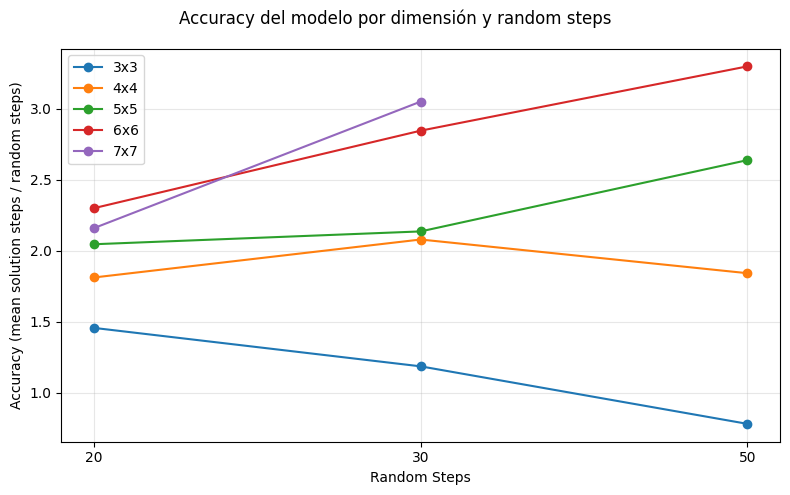

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

random_steps_order = [20, 30, 50]
x = np.arange(3)

fig, ax = plt.subplots(figsize=(8, 5))

for dim in sorted(data.keys()):
    label = f"{dim}x{dim}"
    accuracies = []
    for steps in random_steps_order:
        info = data[dim].get(steps, {})
        mean_steps = info.get("mean_solution_steps")
        if mean_steps is not None and steps and steps > 0:
            accuracies.append(mean_steps / steps)
        else:
            accuracies.append(np.nan)
    if not all(np.isnan(v) for v in accuracies):
        ax.plot(x, accuracies, marker="o", label=label)

ax.set_xticks(x)
ax.set_xticklabels(["20", "30", "50"])
ax.set_xlabel("Random Steps")
ax.set_ylabel("Accuracy (mean solution steps / random steps)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.suptitle("Accuracy del modelo por dimensión y random steps")
plt.tight_layout()
plt.show()